In [2]:
# Importamos todas las librerias necesarias para mostrar y filtrar los datos correctamente
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Aplicamos el estilo de seaborn a los graficos y los mostramos dentro del notebook
sns.set_theme(style="whitegrid")
%matplotlib inline

In [3]:
# Usando la libreria pandas leemos el csv y lo guardamos en una variable para poder utilizarlo, luego mostramos que se ha cargado correctamente
df = pd.read_csv("pokemon.csv")
print(f"Dataset carregat: {df.shape[0]} files i {df.shape[1]} columnes.")

Dataset carregat: 1025 files i 15 columnes.


In [4]:
# Guardamos en una variable solo los pokemon que tienen un habitat
df_habitat = df.dropna(subset=['habitat'])

# Calcula el promedio de base_stat_total por hábitat y ordena de mayor a menor
habitat_promedio = (
    df.groupby("habitat")["base_stat_total"] # Agrupa por hábitat y selecciona la columna base_stat_total
    .mean() # Promedio de cada grupo
    .reset_index() # Convierte "habitat" de índice a columna normal
    .sort_values(by="base_stat_total", ascending=False) # Ordena de mayor a menor promedio
)

In [10]:
#Mostramos el habitat con el promedio mas alto de base_stat_total
# iloc[[0]] selecciona la primera fila (la mayor, porque ya esta ordenada de forma descendente
display(habitat_promedio.iloc[[0]])

,habitat,base_stat_total
4,rare,599.6


In [7]:
# Calculamos la suma de base_stat_total por habitat y lo ordenamos de mayor a menor
habitat_suma = (
    df_habitat.groupby('habitat')['base_stat_total']  # Agrupa por habitat y selecciona la columna base_stat_total
    .sum()                                            # Suma de cada grupo
    .reset_index()                                    # Convierte "habitat" de indice a columna normal
    .sort_values(by='base_stat_total', ascending=False)  # Ordena de mayor a menor suma
)

In [11]:
# Mostramos el habitat con la suma mas alta de base_stat_total
# iloc[[0]] selecciona la primera fila (la mayor, porque ya esta ordenada de forma descendente)
display(habitat_suma.iloc[[0]])

,habitat,base_stat_total
2,grassland,32216


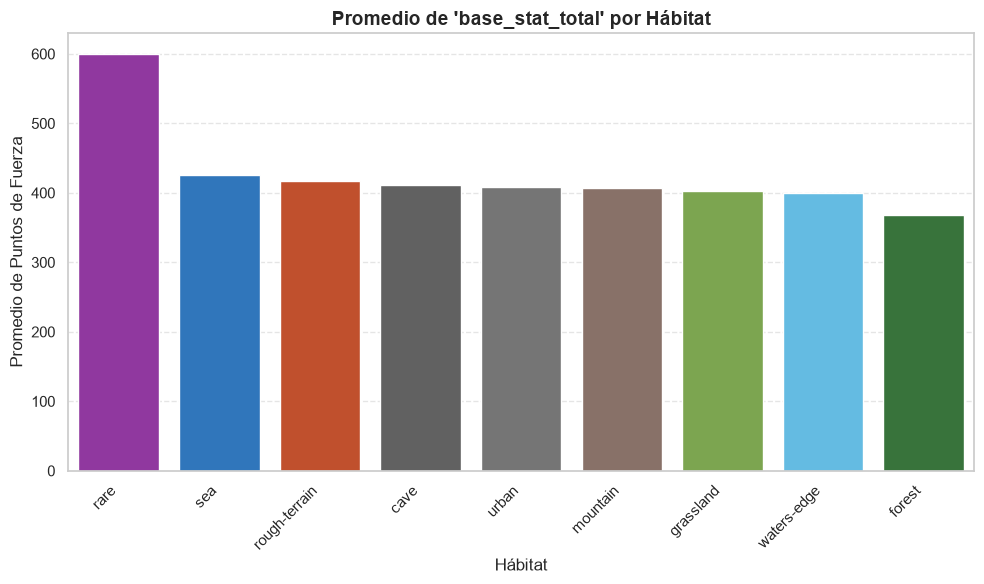

In [12]:
# Diccionario con colores representativos para cada hábitat
colores_habitat = {
    "rare": "#9C27B0",  # Púrpura (Raro / Leyenda)
    "sea": "#1976D2",  # Azul mar (Océano)
    "rough-terrain": "#D84315",  # Naranja terroso (Tierra rugosa)
    "cave": "#616161",  # Gris cueva (Piedra)
    "urban": "#757575",  # Gris metálico (Ciudad)
    "mountain": "#8D6E63",  # Marrón (Montaña)
    "grassland": "#7CB342",  # Verde pradera (Campo)
    "waters-edge": "#4FC3F7",  # Azul claro (Orilla)
    "forest": "#2E7D32",  # Verde oscuro (Bosque)
}

# Configuración del gráfico de columnas verticales
plt.figure(figsize=(10, 6))

sns.barplot(
    data=habitat_promedio,
    x="habitat",
    y="base_stat_total",
    hue="habitat",  # Asigna el hábitat a la paleta
    palette=colores_habitat,  # Mapeo de colores temáticos
    legend=False,
)

plt.title(
    "Promedio de 'base_stat_total' por Hábitat", fontsize=14, fontweight="bold"
)
plt.xlabel("Hábitat", fontsize=12)
plt.ylabel("Promedio de Puntos de Fuerza", fontsize=12)

# Rotar las etiquetas del eje X para mejor lectura
plt.xticks(rotation=45, ha="right")

# Líneas de guía horizontales suaves
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()